In [ ]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

In [ ]:
x,y = sp.symbols('x y')
f = x**2 * sp.exp(y) - 3*x*y**2

grad_f = [sp.diff(f,x), sp.diff(f,y)]
h_f = sp.hessian(f, (x,y))

print("f(x) = ", f)
print("Gradient f= ", grad_f)
print("Hessian f = ", h_f)


f(x) =  x**2*exp(y) - 3*x*y**2
Gradient f=  [2*x*exp(y) - 3*y**2, x**2*exp(y) - 6*x*y]
Hessian f =  Matrix([[2*exp(y), 2*x*exp(y) - 6*y], [2*x*exp(y) - 6*y, x**2*exp(y) - 6*x]])


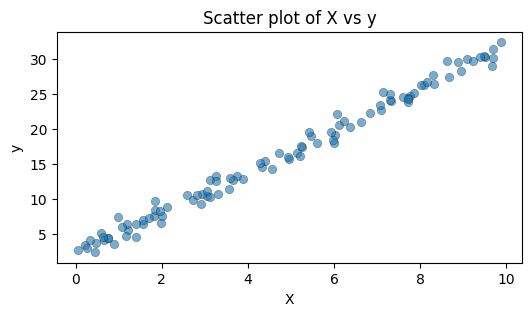

In [ ]:
np.random.seed(42)
X = np.random.uniform(0,10,100)
eps = np.random.randn(100)
y = 3*X + 2 + eps

plt.figure(figsize=(6,3))
plt.scatter(X,y, alpha = 0.6, edgecolors='k', linewidths=0.3)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Scatter plot of X vs y')
plt.show()


In [ ]:
def compute_loss(w, b, X, y):
    N = len(X)
    preds = w * X + b
    return np.sum((preds - y) ** 2) / (2 * N)


def compute_gradients(w, b, X, y):
    N = len(X)
    preds = w * X + b
    error = preds - y                  # = (w*x_i + b - y_i)
    dw = np.sum(error * X) / N
    db = np.sum(error) / N
    return dw, db


def gradient_descent(X, y, w_init, b_init, alpha, epochs):
    w, b = w_init, b_init
    losses = []
    history = [(w, b)]
    for _ in range(epochs):
        losses.append(compute_loss(w, b, X, y))
        dw, db = compute_gradients(w, b, X, y)
        w = w - alpha * dw             # Algorithme 1
        b = b - alpha * db
        history.append((w, b))
    return w, b, losses, history



In [ ]:
w0, b0, alpha0, epochs0 = 0.0, 0.0, 0.01, 100

w_star, b_star, losses, history = gradient_descent(
    X, y, w0, b0, alpha0, epochs0)

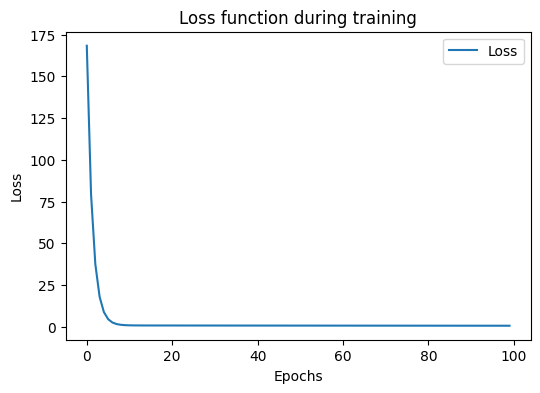

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(losses, label='Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss function during training')
plt.legend()
plt.show()

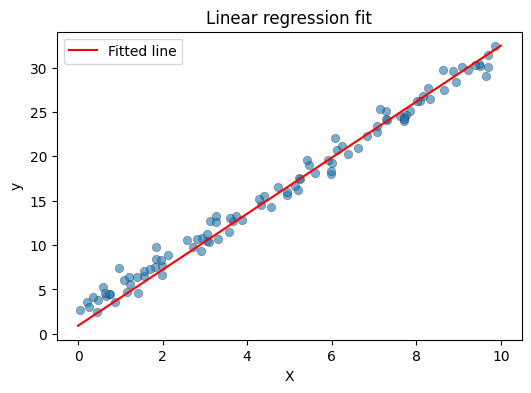

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(X,y, alpha = 0.6, edgecolors='k', linewidths=0.3)
x_line = np.linspace(0,10,100)
y_pred = w_star * x_line + b_star
plt.plot(x_line, y_pred, color='red', label='Fitted line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear regression fit')
plt.legend()
plt.show()

Text(0.5, 1.0, 'Contour plot of loss function with gradient descent path')

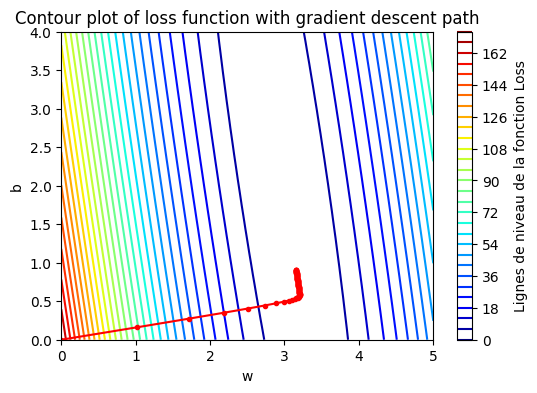

In [ ]:
N = len(X)
S_xx = np.sum(X**2)
S_x = np.sum(X)

hess_ = 1/N * np.array([[S_xx, S_x], [S_x, N]])
eigenvalues = np.linalg.eigvalsh(hess_)
L = np.max(eigenvalues)
alpha_opt = 1/L

w_vals = np.linspace(0, 5, 100)
b_vals = np.linspace(0, 4, 100)
W, B = np.meshgrid(w_vals, b_vals)

L_vals = np.array([[compute_loss(w, b, X, y) for w in w_vals] for b in b_vals])

# cas 1: alpha = 0.01
_,_,_,history = gradient_descent(X, y, 0, 0,0.01, 100)
ws, bs = zip(*history)

plt.figure(figsize=(6,4))
plt.contour(W, B, L_vals, levels=30, cmap='jet')
plt.colorbar(label='Lignes de niveau de la fonction Loss')
plt.plot(ws, bs, '.-', color='red', label='Gradient Descent Path')
plt.xlabel('w')
plt.ylabel('b')
plt.title('Contour plot of loss function with gradient descent path') 



# cas 2:







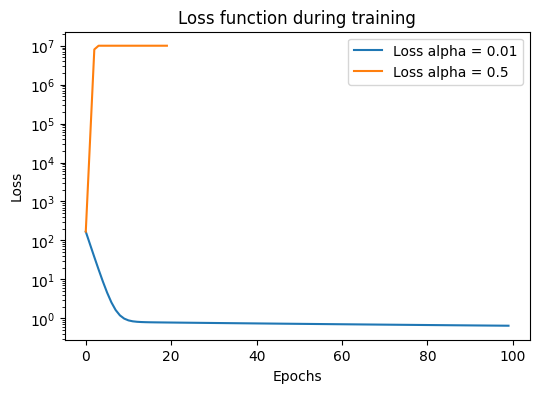

In [ ]:
alpha_ = 0.5
w_big, b_big, losses_big, history_gig = gradient_descent(X, y, 0, 0, alpha_, 100)

losses_big_ = np.clip(losses_big[:20], 0, 1e7)
plt.figure(figsize=(6,4))
plt.semilogy(losses, label='Loss alpha = 0.01')
plt.semilogy(losses_big_, label='Loss alpha = 0.5')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Loss function during training')
plt.legend()
plt.show()